
# IDRiD Dataset 2 — Maximum-Quality Optic Disc + Fovea Localization

> **Corrected strict loader, built from the same error-resistant pattern as your `Corrected81_v2` segmentation notebook.**

This notebook uses **only** the official IDRiD localization subset:

- **413 official training originals**
- **103 official testing originals**
- **516 localization images total**

The 413 official training images are split into train/validation. The 103 official testing images remain untouched until final evaluation. The notebook hard-stops if the expected localization structure/counts are not found, so `A. Segmentation` and `B. Disease Grading` cannot leak into this task.

## Model
**DenseNet121 + scSE Attention Heatmap Decoder + Deep Supervision**

Outputs:
- channel 0 → optic disc center
- channel 1 → fovea center

Quality/robustness measures include strict dataset auditing, aspect-preserving preprocessing, coordinate-safe augmentation, memory-efficient pretrained DenseNet121, frozen encoder BatchNorm statistics, AdamW, gradient accumulation, clipping, EMA, 150-epoch ceiling, early stopping, ReduceLROnPlateau, top-5 checkpoint averaging, 4-way TTA, and untouched official-test evaluation.


In [1]:

# ============================================================
# 1. Imports and reproducibility
# ============================================================
import os, re, gc, json, math, random, shutil, warnings
from copy import deepcopy
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.models import densenet121, DenseNet121_Weights
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
cv2.setNumThreads(0)

SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything()

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP = torch.cuda.is_available()

print("PyTorch:", torch.__version__)
print("Device :", DEVICE)
if torch.cuda.is_available():
    print("GPU    :", torch.cuda.get_device_name(0))


PyTorch: 2.10.0+cu128
Device : cuda
GPU    : Tesla T4


In [2]:

# ============================================================
# 2. Maximum-quality configuration
# ============================================================
LANDMARK_NAMES = ["OD", "FV"]
LANDMARK_FULL_NAMES = {"OD": "Optic Disc", "FV": "Fovea"}
NUM_LANDMARKS = 2

# IDRiD is ~3:2. 960x640 preserves global retinal geometry and is divisible by 32.
INPUT_W, INPUT_H = 960, 640
OUTPUT_STRIDE = 4
HEATMAP_W, HEATMAP_H = INPUT_W // OUTPUT_STRIDE, INPUT_H // OUTPUT_STRIDE
HEATMAP_SIGMA = 3.5

BATCH_SIZE = 1
ACCUMULATION_STEPS = 4
NUM_WORKERS = 2
VAL_FRACTION = 0.20

MAX_EPOCHS = 150
MIN_EPOCHS_BEFORE_STOP = 25
FREEZE_ENCODER_EPOCHS = 5
ENCODER_LR = 5e-5
DECODER_LR = 2e-4
WEIGHT_DECAY = 2e-4
GRAD_CLIP_NORM = 1.0
EARLY_STOPPING_PATIENCE = 25
LR_PATIENCE = 6
LR_FACTOR = 0.5
MIN_LR = 5e-7
EMA_DECAY = 0.999
TOPK_CHECKPOINTS = 5

PEAK_WEIGHT = 12.0
LOSS_W_BCE = 0.45
LOSS_W_MSE = 0.20
LOSS_W_COORD = 0.35
DEEP_SUPERVISION_WEIGHT = 0.30
SOFTARGMAX_TEMPERATURE = 0.25

USE_TTA = True
LOCAL_PEAK_RADIUS = 3
CACHE_RESIZED_IMAGES = True
CACHE_JPEG_QUALITY = 97
PRETRAINED = True
EXPORT_ONNX = True

OUTPUT_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("./outputs_localization")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TOPK_DIR = OUTPUT_DIR / "idrid_localization_topk"
TOPK_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR = OUTPUT_DIR / f"_cache_localization_{INPUT_W}x{INPUT_H}"

BEST_CKPT = OUTPUT_DIR / "idrid_densenet121_localization_best.pth"
AVERAGED_CKPT = OUTPUT_DIR / "idrid_densenet121_localization_topk_avg.pth"
FINAL_BUNDLE = OUTPUT_DIR / "idrid_densenet121_localization_maxquality_bundle.pth"
PLAIN_WEIGHTS = OUTPUT_DIR / "idrid_densenet121_localization_state_dict.pth"
HISTORY_CSV = OUTPUT_DIR / "idrid_localization_training_history.csv"
VAL_PRED_CSV = OUTPUT_DIR / "idrid_localization_validation_predictions_tta.csv"
TEST_PRED_CSV = OUTPUT_DIR / "idrid_localization_official_test_predictions.csv"
TEST_METRICS_JSON = OUTPUT_DIR / "idrid_localization_official_test_metrics.json"
ONNX_PATH = OUTPUT_DIR / "idrid_densenet121_localization.onnx"

CONFIG = {
    "seed": SEED, "landmarks": LANDMARK_NAMES,
    "input_w": INPUT_W, "input_h": INPUT_H,
    "output_stride": OUTPUT_STRIDE,
    "heatmap_w": HEATMAP_W, "heatmap_h": HEATMAP_H,
    "heatmap_sigma": HEATMAP_SIGMA,
    "batch_size": BATCH_SIZE, "accumulation_steps": ACCUMULATION_STEPS,
    "val_fraction": VAL_FRACTION, "max_epochs": MAX_EPOCHS,
    "freeze_encoder_epochs": FREEZE_ENCODER_EPOCHS,
    "encoder_lr": ENCODER_LR, "decoder_lr": DECODER_LR,
    "weight_decay": WEIGHT_DECAY, "ema_decay": EMA_DECAY,
    "topk_checkpoints": TOPK_CHECKPOINTS, "use_tta": USE_TTA,
}
print(json.dumps(CONFIG, indent=2))


{
  "seed": 42,
  "landmarks": [
    "OD",
    "FV"
  ],
  "input_w": 960,
  "input_h": 640,
  "output_stride": 4,
  "heatmap_w": 240,
  "heatmap_h": 160,
  "heatmap_sigma": 3.5,
  "batch_size": 1,
  "accumulation_steps": 4,
  "val_fraction": 0.2,
  "max_epochs": 150,
  "freeze_encoder_epochs": 5,
  "encoder_lr": 5e-05,
  "decoder_lr": 0.0002,
  "weight_decay": 0.0002,
  "ema_decay": 0.999,
  "topk_checkpoints": 5,
  "use_tta": true
}



## 3. Strict localization-only discovery

This follows the corrected segmentation notebook's loader strategy: do not guess the Kaggle slug, identify the inner task folder by its structure, classify official train/test paths explicitly, and hard-stop on unexpected counts.


In [3]:

# ============================================================
# 3. STRICT IDRiD LOCALIZATION-ONLY discovery
# ============================================================
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
ID_RE = re.compile(r"(IDRID[_-]?\d+)", re.IGNORECASE)

EXPECTED_TRAIN_IMAGES = 413
EXPECTED_TEST_IMAGES = 103
EXPECTED_TOTAL_IMAGES = 516

def clean_path_string(path):
    return str(path).lower().replace("\\", "/")

def normalize_id(value):
    # Supports IDRiD_001, IDRID-001, IDRID001, 1, 001.
    s = str(value).strip()
    m = ID_RE.search(s)
    if m:
        digits = re.findall(r"\d+", m.group(1))
        if digits:
            return f"IDRID_{int(digits[-1]):03d}"
    numeric = re.sub(r"\.0$", "", s)
    if re.fullmatch(r"\d+", numeric):
        return f"IDRID_{int(numeric):03d}"
    return None

def is_training_path(path):
    p = clean_path_string(path)
    return ("training set" in p or "/train/" in p or "/training/" in p or "/a. training set/" in p)

def is_testing_path(path):
    p = clean_path_string(path)
    return ("testing set" in p or "/test/" in p or "/testing/" in p or "/b. testing set/" in p)

def locate_dataset_root():
    kaggle_input = Path("/kaggle/input")
    if not kaggle_input.exists():
        raise RuntimeError("/kaggle/input was not found. Run this notebook on Kaggle.")
    top = [p for p in kaggle_input.iterdir() if p.is_dir()]
    if not top:
        raise RuntimeError("No Kaggle input is attached. Add Dataset 2 first.")
    print("Attached Kaggle input folders:")
    for p in top:
        print("  -", p)
    return kaggle_input

def find_localization_root(data_root):
    candidates = []
    dirs = [data_root] + [p for p in data_root.rglob("*") if p.is_dir()]
    for d in dirs:
        try:
            children = [x for x in d.iterdir() if x.is_dir()]
        except Exception:
            continue
        names = [x.name.lower().strip() for x in children]
        has_original = any("original image" in n for n in names)
        has_gt = any(("groundtruth" in n or "ground truth" in n) for n in names)
        if not (has_original and has_gt):
            continue
        score = 0
        if "localization" in d.name.lower():
            score -= 100
        p = clean_path_string(d)
        if "/c. localization/" in p or p.endswith("/c. localization"):
            score -= 50
        score -= len(d.parts)
        candidates.append((score, d))
    if not candidates:
        likely = [str(d) for d in dirs if "localization" in d.name.lower()]
        msg = "Could not find the inner C. Localization folder containing Original Images and Groundtruths."
        if likely:
            msg += "\nLocalization-like folders found:\n  " + "\n  ".join(likely[:30])
        raise RuntimeError(msg)
    candidates.sort(key=lambda x: x[0])
    chosen = candidates[0][1]
    print("\nLocalization candidates:")
    for _, p in candidates[:10]:
        print("  -", p)
    print("\nSelected localization root:", chosen)
    return chosen

DATA_ROOT = locate_dataset_root()
LOC_ROOT = find_localization_root(DATA_ROOT)

children = [p for p in LOC_ROOT.iterdir() if p.is_dir()]
ORIGINAL_ROOTS = [p for p in children if "original image" in p.name.lower()]
GT_ROOTS = [p for p in children if ("groundtruth" in p.name.lower() or "ground truth" in p.name.lower())]

assert len(ORIGINAL_ROOTS) == 1, f"Expected one Original Images branch; found {ORIGINAL_ROOTS}"
assert len(GT_ROOTS) == 1, f"Expected one Groundtruths branch; found {GT_ROOTS}"

ORIGINAL_ROOT = ORIGINAL_ROOTS[0]
GT_ROOT = GT_ROOTS[0]

print("Original-images root:", ORIGINAL_ROOT)
print("Groundtruths root   :", GT_ROOT)


Attached Kaggle input folders:
  - /kaggle/input/datasets

Localization candidates:
  - /kaggle/input/datasets/yashraneja/dataset-2/Dataset 2/C. Localization/C. Localization
  - /kaggle/input/datasets/yashraneja/dataset-2/Dataset 2/B. Disease Grading/B. Disease Grading
  - /kaggle/input/datasets/yashraneja/dataset-2/Dataset 2/A. Segmentation/A. Segmentation

Selected localization root: /kaggle/input/datasets/yashraneja/dataset-2/Dataset 2/C. Localization/C. Localization
Original-images root: /kaggle/input/datasets/yashraneja/dataset-2/Dataset 2/C. Localization/C. Localization/1. Original Images
Groundtruths root   : /kaggle/input/datasets/yashraneja/dataset-2/Dataset 2/C. Localization/C. Localization/2. Groundtruths


In [4]:

# ============================================================
# 4. Strict original-image indexing by official split
# ============================================================
all_original_files = [p for p in ORIGINAL_ROOT.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS]
train_files, test_files, unknown_files = [], [], []

for p in all_original_files:
    if is_training_path(p):
        train_files.append(p)
    elif is_testing_path(p):
        test_files.append(p)
    else:
        unknown_files.append(p)

def unique_images_by_id(files, split_name):
    by_id, duplicates = {}, {}
    for p in sorted(files):
        iid = normalize_id(p.stem)
        if iid is None:
            continue
        if iid in by_id:
            duplicates.setdefault(iid, [by_id[iid]]).append(p)
        else:
            by_id[iid] = p
    if duplicates:
        raise RuntimeError(f"Duplicate IDs inside {split_name}: {dict(list(duplicates.items())[:20])}")
    return by_id

train_image_map = unique_images_by_id(train_files, "official training")
test_image_map = unique_images_by_id(test_files, "official testing")

print("Official localization originals:")
print("  Training:", len(train_image_map))
print("  Testing :", len(test_image_map))
print("  Total   :", len(train_image_map) + len(test_image_map))

assert len(train_image_map) == EXPECTED_TRAIN_IMAGES, (
    f"STOP: expected {EXPECTED_TRAIN_IMAGES} localization training images, found {len(train_image_map)}. Root={LOC_ROOT}"
)
assert len(test_image_map) == EXPECTED_TEST_IMAGES, (
    f"STOP: expected {EXPECTED_TEST_IMAGES} localization testing images, found {len(test_image_map)}. Root={LOC_ROOT}"
)
assert len(train_image_map) + len(test_image_map) == EXPECTED_TOTAL_IMAGES

if unknown_files:
    print(f"NOTE: ignored {len(unknown_files)} images without a recognized official train/test path marker.")

print("Localization image-count audit: PASSED")


Official localization originals:
  Training: 413
  Testing : 103
  Total   : 516
Localization image-count audit: PASSED


In [5]:

# ============================================================
# 5. Find exactly OD/Fovea train/test coordinate CSVs
# ============================================================
all_csv = [p for p in GT_ROOT.rglob("*") if p.is_file() and p.suffix.lower() == ".csv"]
print("CSV files under Groundtruths:")
for p in all_csv:
    print("  -", p.relative_to(GT_ROOT))

def landmark_kind(path):
    s = clean_path_string(path)
    if "fovea" in s:
        return "FV"
    if "optic" in s:
        return "OD"
    if re.search(r"(^|[^a-z])od([^a-z]|$)", path.name.lower()):
        return "OD"
    return None

def split_kind(path):
    if is_training_path(path):
        return "train"
    if is_testing_path(path):
        return "test"
    return None

coord_csv = {}
for p in all_csv:
    lm, sp = landmark_kind(p), split_kind(p)
    if lm is None or sp is None:
        continue
    key = (lm, sp)
    if key in coord_csv:
        raise RuntimeError(f"More than one CSV matched {key}:\n{coord_csv[key]}\n{p}")
    coord_csv[key] = p

required = [("OD","train"), ("OD","test"), ("FV","train"), ("FV","test")]
missing = [k for k in required if k not in coord_csv]
assert not missing, f"Missing coordinate CSV(s): {missing}. Files seen: {[str(p) for p in all_csv]}"
assert len(coord_csv) == 4, f"Expected four classified localization CSVs; got {coord_csv}"

for k in required:
    print(k, "->", coord_csv[k])


CSV files under Groundtruths:
  - 2. Fovea Center Location/IDRiD_Fovea_Center_Testing Set_Markups.csv
  - 2. Fovea Center Location/IDRiD_Fovea_Center_Training Set_Markups.csv
  - 1. Optic Disc Center Location/a. IDRiD_OD_Center_Training Set_Markups.csv
  - 1. Optic Disc Center Location/b. IDRiD_OD_Center_Testing Set_Markups.csv
('OD', 'train') -> /kaggle/input/datasets/yashraneja/dataset-2/Dataset 2/C. Localization/C. Localization/2. Groundtruths/1. Optic Disc Center Location/a. IDRiD_OD_Center_Training Set_Markups.csv
('OD', 'test') -> /kaggle/input/datasets/yashraneja/dataset-2/Dataset 2/C. Localization/C. Localization/2. Groundtruths/1. Optic Disc Center Location/b. IDRiD_OD_Center_Testing Set_Markups.csv
('FV', 'train') -> /kaggle/input/datasets/yashraneja/dataset-2/Dataset 2/C. Localization/C. Localization/2. Groundtruths/2. Fovea Center Location/IDRiD_Fovea_Center_Training Set_Markups.csv
('FV', 'test') -> /kaggle/input/datasets/yashraneja/dataset-2/Dataset 2/C. Localization/C. L

In [6]:

# ============================================================
# 6. Robust coordinate CSV parser and split-specific pairing
#    FIX v3: official IDRiD coordinate CSVs may contain trailing
#    completely blank rows. These appear in pandas as NaN rows.
# ============================================================
def norm_col(c):
    return re.sub(r"[^a-z0-9]", "", str(c).lower())


def choose_col(df, role):
    """
    Choose columns by BOTH header name and actual content.

    This is intentionally defensive because some IDRiD CSV copies contain:
      - trailing blank rows
      - unnamed/index columns
      - slightly different coordinate header spelling
    """
    mapping = {c: norm_col(c) for c in df.columns}

    if role == "image":
        # 1) Strong header matches first.
        preferred = []
        for c, n in mapping.items():
            if n in {"imageno", "imageid", "image", "image_no"}:
                preferred.append(c)
            elif "image" in n and ("no" in n or "id" in n):
                preferred.append(c)

        # Return the preferred column that actually contains the most
        # recognizable IDRiD image IDs.
        if preferred:
            scores = []
            for c in preferred:
                score = df[c].dropna().astype(str).map(normalize_id).notna().sum()
                scores.append((int(score), c))
            scores.sort(reverse=True, key=lambda x: x[0])
            if scores[0][0] > 0:
                return scores[0][1]

        # 2) Content-based fallback: find the column whose non-null values
        # normalize most often to IDRID_###.
        scores = []
        for c in df.columns:
            non_null = df[c].dropna()
            if len(non_null) == 0:
                continue
            score = non_null.astype(str).map(normalize_id).notna().sum()
            scores.append((int(score), c))

        if scores:
            scores.sort(reverse=True, key=lambda x: x[0])
            if scores[0][0] > 0:
                return scores[0][1]

        return None

    if role == "x":
        exact = {
            "x", "xcoordinate", "xcoordinates", "xcoordinateofcenter",
            "xcoordinateod", "xcoordinatefovea"
        }
        for c, n in mapping.items():
            if n in exact or n.startswith("xcoordinate") or n.endswith("xcoordinate"):
                return c

    if role == "y":
        exact = {
            "y", "ycoordinate", "ycoordinates", "ycoordinateofcenter",
            "ycoordinateod", "ycoordinatefovea"
        }
        for c, n in mapping.items():
            if n in exact or n.startswith("ycoordinate") or n.endswith("ycoordinate"):
                return c

    return None


def read_landmark_csv(path, prefix, expected_rows):
    # Read normally first. Official/republished IDRiD CSVs can contain many
    # blank spreadsheet rows after the real records.
    df = pd.read_csv(path)

    original_rows = len(df)

    # Remove rows that are completely blank.
    df = df.dropna(how="all").copy()

    # Remove completely empty columns (e.g. "Unnamed: 3" exported by Excel).
    df = df.dropna(axis=1, how="all").copy()

    if df.empty:
        raise RuntimeError(f"{path.name}: CSV is empty after removing blank rows/columns.")

    image_col = choose_col(df, "image")
    x_col = choose_col(df, "x")
    y_col = choose_col(df, "y")

    if image_col is None:
        raise RuntimeError(
            f"Could not identify the image-ID column in {path.name}.\n"
            f"Columns found: {list(df.columns)}\n"
            f"First rows:\n{df.head(8).to_string(index=False)}"
        )

    # If X/Y headers are unusual, choose the two most numeric non-image columns.
    if x_col is None or y_col is None:
        candidates = []
        for c in df.columns:
            if c == image_col:
                continue
            numeric_values = pd.to_numeric(df[c], errors="coerce")
            numeric_count = int(numeric_values.notna().sum())
            candidates.append((numeric_count, c))

        candidates.sort(reverse=True, key=lambda x: x[0])
        numeric_cols = [c for count, c in candidates if count > 0]

        if x_col is None and len(numeric_cols) >= 1:
            x_col = numeric_cols[0]

        if y_col is None:
            for c in numeric_cols:
                if c != x_col:
                    y_col = c
                    break

    if x_col is None or y_col is None:
        raise RuntimeError(
            f"Could not identify coordinate columns in {path.name}.\n"
            f"Columns found: {list(df.columns)}\n"
            f"Selected image column: {image_col}\n"
            f"First rows:\n{df.head(8).to_string(index=False)}"
        )

    # Keep only the three relevant columns.
    out = df[[image_col, x_col, y_col]].copy()
    out.columns = ["raw_image_id", f"{prefix}_x", f"{prefix}_y"]

    # IMPORTANT FIX:
    # Some official/repacked IDRiD CSVs have trailing rows where Image No is NaN.
    # Those are spreadsheet padding, not dataset samples.
    out = out[out["raw_image_id"].notna()].copy()

    # Normalize IDs. Rows that still do not resemble an IDRiD image ID are
    # treated as non-data/header/footer rows and removed, but we report them.
    out["image_id"] = out["raw_image_id"].astype(str).map(normalize_id)

    invalid_id_mask = out["image_id"].isna()
    if invalid_id_mask.any():
        invalid_values = (
            out.loc[invalid_id_mask, "raw_image_id"]
            .astype(str)
            .head(20)
            .tolist()
        )
        print(
            f"NOTE: {path.name}: dropping {int(invalid_id_mask.sum())} "
            f"non-data row(s) that are not valid image IDs. Examples: {invalid_values}"
        )
        out = out.loc[~invalid_id_mask].copy()

    # Convert coordinates only after the real image rows have been isolated.
    out[f"{prefix}_x"] = pd.to_numeric(out[f"{prefix}_x"], errors="coerce")
    out[f"{prefix}_y"] = pd.to_numeric(out[f"{prefix}_y"], errors="coerce")

    bad_coord_mask = out[[f"{prefix}_x", f"{prefix}_y"]].isna().any(axis=1)
    if bad_coord_mask.any():
        bad = out.loc[
            bad_coord_mask,
            ["raw_image_id", f"{prefix}_x", f"{prefix}_y"]
        ].head(20)

        raise RuntimeError(
            f"{path.name}: real image rows contain missing/non-numeric coordinates.\n"
            f"{bad.to_string(index=False)}"
        )

    # Duplicate IDs are a real data problem and must not be silently removed.
    if out["image_id"].duplicated().any():
        dup = (
            out.loc[out["image_id"].duplicated(keep=False), "image_id"]
            .tolist()
        )
        raise RuntimeError(
            f"{path.name}: duplicate image IDs found: {dup[:30]}"
        )

    out = (
        out[["image_id", f"{prefix}_x", f"{prefix}_y"]]
        .sort_values("image_id")
        .reset_index(drop=True)
    )

    print(
        f"{path.name}\n"
        f"  raw pandas rows       : {original_rows}\n"
        f"  valid landmark rows   : {len(out)}\n"
        f"  selected columns      : image='{image_col}', x='{x_col}', y='{y_col}'"
    )

    if len(out) != expected_rows:
        raise RuntimeError(
            f"{path.name}: expected {expected_rows} valid landmark rows, "
            f"but found {len(out)} after cleaning.\n"
            "This usually means the wrong CSV was selected or the file has been altered."
        )

    return out


od_train = read_landmark_csv(
    coord_csv[("OD", "train")],
    "od",
    EXPECTED_TRAIN_IMAGES,
)

od_test = read_landmark_csv(
    coord_csv[("OD", "test")],
    "od",
    EXPECTED_TEST_IMAGES,
)

fv_train = read_landmark_csv(
    coord_csv[("FV", "train")],
    "fv",
    EXPECTED_TRAIN_IMAGES,
)

fv_test = read_landmark_csv(
    coord_csv[("FV", "test")],
    "fv",
    EXPECTED_TEST_IMAGES,
)

# Merge only after each source independently passes the expected-count checks.
train_labels = od_train.merge(
    fv_train,
    on="image_id",
    how="inner",
    validate="one_to_one",
)

test_labels = od_test.merge(
    fv_test,
    on="image_id",
    how="inner",
    validate="one_to_one",
)

if len(train_labels) != EXPECTED_TRAIN_IMAGES:
    missing_od = sorted(set(fv_train.image_id) - set(od_train.image_id))
    missing_fv = sorted(set(od_train.image_id) - set(fv_train.image_id))
    raise RuntimeError(
        f"Training OD/Fovea ID mismatch after merge.\n"
        f"Missing OD rows for: {missing_od[:20]}\n"
        f"Missing Fovea rows for: {missing_fv[:20]}"
    )

if len(test_labels) != EXPECTED_TEST_IMAGES:
    missing_od = sorted(set(fv_test.image_id) - set(od_test.image_id))
    missing_fv = sorted(set(od_test.image_id) - set(fv_test.image_id))
    raise RuntimeError(
        f"Testing OD/Fovea ID mismatch after merge.\n"
        f"Missing OD rows for: {missing_od[:20]}\n"
        f"Missing Fovea rows for: {missing_fv[:20]}"
    )


def attach_images(df, image_map, official_split):
    out = df.copy()
    out["image_path"] = out["image_id"].map(image_map)
    out["official_split"] = official_split

    missing = out.loc[out["image_path"].isna(), "image_id"].tolist()
    if missing:
        raise RuntimeError(
            f"{official_split}: coordinate rows without matching images: {missing[:20]}"
        )

    image_ids = set(image_map)
    csv_ids = set(out["image_id"])

    if image_ids != csv_ids:
        raise RuntimeError(
            f"{official_split}: image/CSV mismatch.\n"
            f"Images missing from CSV: {sorted(image_ids - csv_ids)[:20]}\n"
            f"CSV IDs missing from images: {sorted(csv_ids - image_ids)[:20]}"
        )

    return out


train_df = attach_images(
    train_labels,
    train_image_map,
    "train",
)

test_df = attach_images(
    test_labels,
    test_image_map,
    "test",
)

print("\nImage/coordinate pairing audit: PASSED")
print(f"Training pairs: {len(train_df)}")
print(f"Testing pairs : {len(test_df)}")


a. IDRiD_OD_Center_Training Set_Markups.csv
  raw pandas rows       : 515
  valid landmark rows   : 413
  selected columns      : image='Image No', x='X- Coordinate', y='Y - Coordinate'
b. IDRiD_OD_Center_Testing Set_Markups.csv
  raw pandas rows       : 515
  valid landmark rows   : 103
  selected columns      : image='Image No', x='X- Coordinate', y='Y - Coordinate'
IDRiD_Fovea_Center_Training Set_Markups.csv
  raw pandas rows       : 515
  valid landmark rows   : 413
  selected columns      : image='Image No', x='X- Coordinate', y='Y - Coordinate'
IDRiD_Fovea_Center_Testing Set_Markups.csv
  raw pandas rows       : 515
  valid landmark rows   : 103
  selected columns      : image='Image No', x='X- Coordinate', y='Y - Coordinate'

Image/coordinate pairing audit: PASSED
Training pairs: 413
Testing pairs : 103


In [7]:

# ============================================================
# 7. Native dimensions + coordinate-bounds audit
# ============================================================
def add_sizes(df):
    ws, hs = [], []
    for p in df["image_path"]:
        img = cv2.imread(str(p), cv2.IMREAD_COLOR)
        if img is None:
            raise RuntimeError(f"Could not read image: {p}")
        h,w = img.shape[:2]
        ws.append(w); hs.append(h)
    out = df.copy()
    out["orig_w"], out["orig_h"] = ws, hs
    return out

train_df = add_sizes(train_df)
test_df = add_sizes(test_df)

def audit_coords(df, name):
    valid = (
        (df.od_x >= 0) & (df.od_x < df.orig_w) &
        (df.od_y >= 0) & (df.od_y < df.orig_h) &
        (df.fv_x >= 0) & (df.fv_x < df.orig_w) &
        (df.fv_y >= 0) & (df.fv_y < df.orig_h)
    )
    bad = df.loc[~valid]
    print(f"{name}: {len(df)} rows | invalid={len(bad)}")
    if len(bad):
        display(bad.head(20))
        raise RuntimeError(f"Invalid coordinates in {name}")

audit_coords(train_df, "Official training")
audit_coords(test_df, "Official testing")
display(train_df.groupby(["orig_w","orig_h"]).size().reset_index(name="count").sort_values("count",ascending=False).head())


Official training: 413 rows | invalid=0
Official testing: 103 rows | invalid=0


,orig_w,orig_h,count
0,4288,2848,413


In [8]:

# ============================================================
# 8. Leakage-safe split from ONLY the 413 official training images
# ============================================================
split_df = train_df.copy()
split_df["od_side"] = ((split_df.od_x / np.maximum(split_df.orig_w - 1, 1)) >= 0.5).astype(int)
idx = np.arange(len(split_df))
labels = split_df["od_side"].to_numpy()

if len(np.unique(labels)) >= 2 and np.min(np.bincount(labels)) >= 2:
    tr_idx, va_idx = train_test_split(
        idx, test_size=VAL_FRACTION, random_state=SEED, shuffle=True, stratify=labels
    )
else:
    print("WARNING: OD-side stratification unavailable; deterministic random split used.")
    tr_idx, va_idx = train_test_split(idx, test_size=VAL_FRACTION, random_state=SEED, shuffle=True)

tr_df = split_df.iloc[tr_idx].drop(columns=["od_side"]).reset_index(drop=True)
va_df = split_df.iloc[va_idx].drop(columns=["od_side"]).reset_index(drop=True)

print("Train:", len(tr_df), "| Val:", len(va_df), "| Official test:", len(test_df))

train_paths = set(map(str,tr_df.image_path))
val_paths = set(map(str,va_df.image_path))
test_paths = set(map(str,test_df.image_path))
assert train_paths.isdisjoint(val_paths)
assert train_paths.isdisjoint(test_paths)
assert val_paths.isdisjoint(test_paths)
assert train_paths | val_paths == set(map(str,train_df.image_path))

tr_df.to_csv(OUTPUT_DIR/"localization_train_split.csv",index=False)
va_df.to_csv(OUTPUT_DIR/"localization_val_split.csv",index=False)
test_df.to_csv(OUTPUT_DIR/"localization_official_test.csv",index=False)
print("Leakage check: PASSED. Official test remains untouched.")


Train: 330 | Val: 83 | Official test: 103
Leakage check: PASSED. Official test remains untouched.


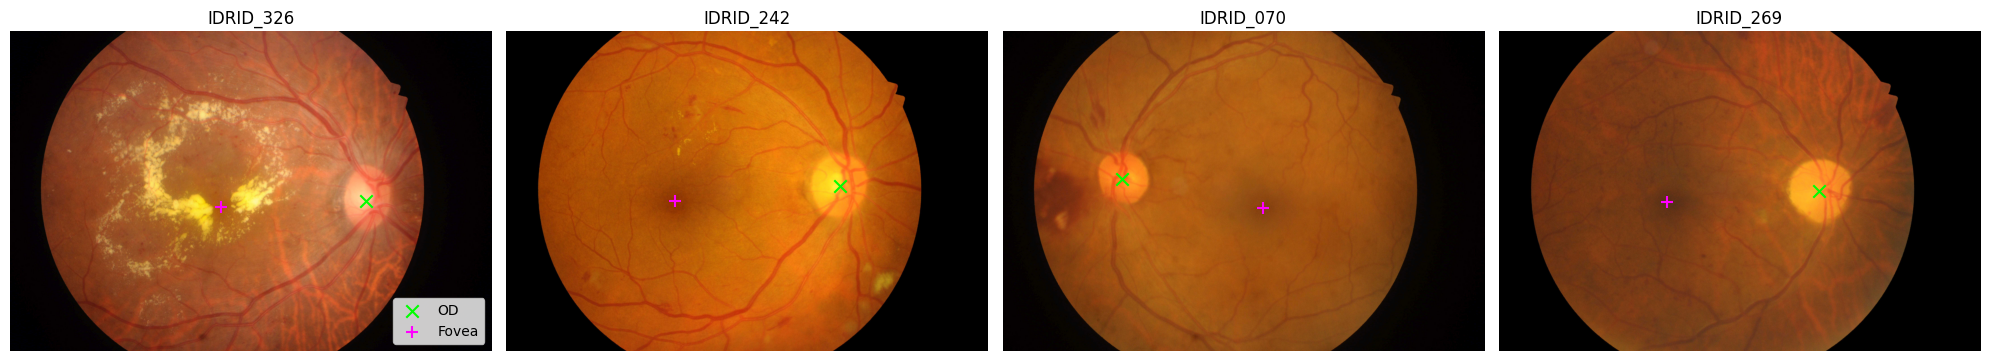

In [9]:

# ============================================================
# 9. Visual label sanity check
# ============================================================
def show_landmarks(df, n=4):
    sample = df.sample(min(n,len(df)), random_state=SEED)
    fig = plt.figure(figsize=(5*len(sample),5))
    for i,(_,r) in enumerate(sample.iterrows(),1):
        ax = fig.add_subplot(1,len(sample),i)
        img = cv2.cvtColor(cv2.imread(str(r.image_path)), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.scatter([r.od_x],[r.od_y],s=80,marker="x",c="lime",label="OD")
        ax.scatter([r.fv_x],[r.fv_y],s=80,marker="+",c="magenta",label="Fovea")
        ax.set_title(r.image_id); ax.axis("off")
        if i == 1: ax.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR/"localization_groundtruth_audit.png",dpi=160,bbox_inches="tight")
    plt.show()
show_landmarks(tr_df)


In [10]:

# ============================================================
# 10. Aspect-preserving preprocessing + coordinate-safe augmentation
# ============================================================
IMAGENET_MEAN = np.array([0.485,0.456,0.406],dtype=np.float32)
IMAGENET_STD  = np.array([0.229,0.224,0.225],dtype=np.float32)

def letterbox_geometry(orig_w, orig_h):
    scale = min(INPUT_W/orig_w, INPUT_H/orig_h)
    nw, nh = int(round(orig_w*scale)), int(round(orig_h*scale))
    left, top = (INPUT_W-nw)//2, (INPUT_H-nh)//2
    right, bottom = INPUT_W-nw-left, INPUT_H-nh-top
    return scale,nw,nh,left,top,right,bottom

def letterbox_image(rgb):
    h,w = rgb.shape[:2]
    scale,nw,nh,left,top,right,bottom = letterbox_geometry(w,h)
    interp = cv2.INTER_AREA if scale < 1 else cv2.INTER_CUBIC
    r = cv2.resize(rgb,(nw,nh),interpolation=interp)
    out = cv2.copyMakeBorder(r,top,bottom,left,right,cv2.BORDER_CONSTANT,value=(0,0,0))
    assert out.shape[:2] == (INPUT_H,INPUT_W)
    return out

def original_to_input_xy(x,y,ow,oh):
    s,_,_,l,t,_,_ = letterbox_geometry(ow,oh)
    return float(x*s+l), float(y*s+t)

def input_to_original_xy(x,y,ow,oh):
    s,_,_,l,t,_,_ = letterbox_geometry(ow,oh)
    xo = np.clip((float(x)-l)/s,0,ow-1)
    yo = np.clip((float(y)-t)/s,0,oh-1)
    return float(xo),float(yo)

def random_clahe_rgb(image):
    lab=cv2.cvtColor(image,cv2.COLOR_RGB2LAB); l,a,b=cv2.split(lab)
    l=cv2.createCLAHE(clipLimit=random.uniform(1.3,2.2),tileGridSize=(8,8)).apply(l)
    return cv2.cvtColor(cv2.merge([l,a,b]),cv2.COLOR_LAB2RGB)

def transform_points(points,M):
    pts=np.asarray(points,dtype=np.float32)
    homo=np.concatenate([pts,np.ones((len(pts),1),dtype=np.float32)],axis=1)
    out=homo@M.T
    return [(float(x),float(y)) for x,y in out]

def inside(points):
    return all(0<=x<INPUT_W and 0<=y<INPUT_H for x,y in points)

def augment_joint(image,points):
    points=[(float(x),float(y)) for x,y in points]
    if random.random()<0.5:
        image=np.ascontiguousarray(image[:,::-1]); points=[(INPUT_W-1-x,y) for x,y in points]
    if random.random()<0.12:
        image=np.ascontiguousarray(image[::-1,:]); points=[(x,INPUT_H-1-y) for x,y in points]
    if random.random()<0.70:
        base_img=image; base_pts=list(points)
        for _ in range(4):
            angle=random.uniform(-10,10); sc=random.uniform(0.94,1.06)
            tx=random.uniform(-0.03,0.03)*INPUT_W; ty=random.uniform(-0.03,0.03)*INPUT_H
            M=cv2.getRotationMatrix2D((INPUT_W/2,INPUT_H/2),angle,sc)
            M[0,2]+=tx; M[1,2]+=ty
            cand=transform_points(base_pts,M)
            if inside(cand):
                image=cv2.warpAffine(base_img,M,(INPUT_W,INPUT_H),flags=cv2.INTER_LINEAR,
                                     borderMode=cv2.BORDER_CONSTANT,borderValue=(0,0,0))
                points=cand
                break
    if random.random()<0.60:
        alpha=random.uniform(0.85,1.15); beta=random.uniform(-12,12)
        image=np.clip(image.astype(np.float32)*alpha+beta,0,255).astype(np.uint8)
    if random.random()<0.35:
        gamma=random.uniform(0.85,1.20)
        lut=np.array([((i/255.)**gamma)*255 for i in range(256)]).astype("uint8")
        image=cv2.LUT(image,lut)
    if random.random()<0.25:
        image=random_clahe_rgb(image)
    r=random.random()
    if r<0.08: image=cv2.GaussianBlur(image,(3,3),0)
    elif r<0.16:
        blur=cv2.GaussianBlur(image,(0,0),1.0); image=cv2.addWeighted(image,1.30,blur,-0.30,0)
    if random.random()<0.15:
        noise=np.random.normal(0,random.uniform(1,4),image.shape).astype(np.float32)
        image=np.clip(image.astype(np.float32)+noise,0,255).astype(np.uint8)
    return image,points

def normalize_image(image):
    x=image.astype(np.float32)/255.
    x=(x-IMAGENET_MEAN)/IMAGENET_STD
    return np.transpose(x,(2,0,1)).astype(np.float32)

def gaussian_heatmap(h,w,x,y,sigma):
    yy,xx=np.mgrid[0:h,0:w].astype(np.float32)
    return np.exp(-((xx-x)**2+(yy-y)**2)/(2*sigma**2)).astype(np.float32)


In [11]:

# ============================================================
# 11. Cache + Dataset + DataLoaders
# ============================================================
def cache_path(row):
    return CACHE_DIR/f"{row['official_split']}_{row['image_id']}.jpg"

def build_cache(df):
    if not CACHE_RESIZED_IMAGES: return
    CACHE_DIR.mkdir(parents=True,exist_ok=True)
    new=0
    for _,r in df.iterrows():
        dst=cache_path(r)
        if dst.exists(): continue
        bgr=cv2.imread(str(r.image_path),cv2.IMREAD_COLOR)
        if bgr is None: raise RuntimeError(f"Could not read {r.image_path}")
        rgb=cv2.cvtColor(bgr,cv2.COLOR_BGR2RGB)
        out=letterbox_image(rgb)
        ok=cv2.imwrite(str(dst),cv2.cvtColor(out,cv2.COLOR_RGB2BGR),
                       [int(cv2.IMWRITE_JPEG_QUALITY),CACHE_JPEG_QUALITY])
        if not ok: raise RuntimeError(f"Could not write cache file {dst}")
        new+=1
    print("Cache ready:",CACHE_DIR,"| new files:",new)

build_cache(pd.concat([train_df,test_df],ignore_index=True))

class IDRiDLocalizationDataset(Dataset):
    def __init__(self,df,train=False):
        self.df=df.reset_index(drop=True).copy(); self.train=train
    def __len__(self): return len(self.df)
    def __getitem__(self,idx):
        r=self.df.iloc[idx]
        if CACHE_RESIZED_IMAGES:
            bgr=cv2.imread(str(cache_path(r)),cv2.IMREAD_COLOR)
            if bgr is None: raise RuntimeError(f"Could not read cache for {r.image_id}")
            image=cv2.cvtColor(bgr,cv2.COLOR_BGR2RGB)
        else:
            bgr=cv2.imread(str(r.image_path),cv2.IMREAD_COLOR)
            if bgr is None: raise RuntimeError(f"Could not read {r.image_path}")
            image=letterbox_image(cv2.cvtColor(bgr,cv2.COLOR_BGR2RGB))
        points=[
            original_to_input_xy(r.od_x,r.od_y,r.orig_w,r.orig_h),
            original_to_input_xy(r.fv_x,r.fv_y,r.orig_w,r.orig_h),
        ]
        if self.train: image,points=augment_joint(image,points)
        hp=[]
        for x,y in points:
            hp.append((x/(INPUT_W-1)*(HEATMAP_W-1), y/(INPUT_H-1)*(HEATMAP_H-1)))
        hms=np.stack([gaussian_heatmap(HEATMAP_H,HEATMAP_W,x,y,HEATMAP_SIGMA) for x,y in hp],axis=0)
        target_xy=np.asarray([[x/(HEATMAP_W-1),y/(HEATMAP_H-1)] for x,y in hp],dtype=np.float32)
        return {
            "image":torch.from_numpy(normalize_image(image)),
            "heatmap":torch.from_numpy(hms).float(),
            "target_xy":torch.from_numpy(target_xy).float(),
            "meta":{
                "image_id":r.image_id, "official_split":r.official_split, "image_path":str(r.image_path),
                "orig_w":int(r.orig_w),"orig_h":int(r.orig_h),
                "od_x":float(r.od_x),"od_y":float(r.od_y),"fv_x":float(r.fv_x),"fv_y":float(r.fv_y),
            }
        }

train_ds=IDRiDLocalizationDataset(tr_df,True)
val_ds=IDRiDLocalizationDataset(va_df,False)
test_ds=IDRiDLocalizationDataset(test_df,False)

loader_kwargs=dict(batch_size=BATCH_SIZE,num_workers=NUM_WORKERS,pin_memory=torch.cuda.is_available())
if NUM_WORKERS>0: loader_kwargs.update(dict(persistent_workers=True,prefetch_factor=2))
train_loader=DataLoader(train_ds,shuffle=True,drop_last=False,**loader_kwargs)
val_loader=DataLoader(val_ds,shuffle=False,drop_last=False,**loader_kwargs)
test_loader=DataLoader(test_ds,shuffle=False,drop_last=False,**loader_kwargs)

b=next(iter(train_loader))
print("Image:",tuple(b["image"].shape),"Heatmap:",tuple(b["heatmap"].shape),"XY:",tuple(b["target_xy"].shape))


Cache ready: /kaggle/working/_cache_localization_960x640 | new files: 516
Image: (1, 3, 640, 960) Heatmap: (1, 2, 160, 240) XY: (1, 2, 2)


In [12]:

# ============================================================
# 12. DenseNet121 + scSE attention heatmap decoder
# ============================================================
def make_group_norm(channels):
    for groups in (16,8,4,2,1):
        if channels%groups==0: return nn.GroupNorm(groups,channels)
    return nn.GroupNorm(1,channels)

class SCSE(nn.Module):
    def __init__(self,channels,reduction=16):
        super().__init__(); hidden=max(channels//reduction,8)
        self.cse=nn.Sequential(nn.AdaptiveAvgPool2d(1),nn.Conv2d(channels,hidden,1),nn.ReLU(inplace=True),
                               nn.Conv2d(hidden,channels,1),nn.Sigmoid())
        self.sse=nn.Sequential(nn.Conv2d(channels,1,1),nn.Sigmoid())
    def forward(self,x): return x*self.cse(x)+x*self.sse(x)

class ConvGNAct(nn.Module):
    def __init__(self,in_ch,out_ch,dropout=0.0):
        super().__init__()
        layers=[nn.Conv2d(in_ch,out_ch,3,padding=1,bias=False),make_group_norm(out_ch),nn.SiLU(inplace=True),
                nn.Conv2d(out_ch,out_ch,3,padding=1,bias=False),make_group_norm(out_ch),nn.SiLU(inplace=True),SCSE(out_ch)]
        if dropout>0: layers.append(nn.Dropout2d(dropout))
        self.block=nn.Sequential(*layers)
    def forward(self,x): return self.block(x)

class UpAttentionBlock(nn.Module):
    def __init__(self,in_ch,skip_ch,out_ch,dropout=0.0):
        super().__init__(); self.conv=ConvGNAct(in_ch+skip_ch,out_ch,dropout)
    def forward(self,x,skip):
        x=F.interpolate(x,size=skip.shape[-2:],mode="bilinear",align_corners=False)
        return self.conv(torch.cat([x,skip],dim=1))

class DenseNet121LocalizationNet(nn.Module):
    def __init__(self,num_landmarks=2,pretrained=True):
        super().__init__()
        weights=DenseNet121_Weights.DEFAULT if pretrained else None
        try:
            backbone=densenet121(weights=weights,memory_efficient=True)
            if pretrained: print("Loaded ImageNet-pretrained memory-efficient DenseNet121.")
        except Exception as e:
            print("WARNING: pretrained weights unavailable:",e)
            backbone=densenet121(weights=None,memory_efficient=True)
        f=backbone.features
        self.enc0=nn.Sequential(f.conv0,f.norm0,f.relu0); self.pool0=f.pool0
        self.enc1=f.denseblock1; self.tr1=f.transition1
        self.enc2=f.denseblock2; self.tr2=f.transition2
        self.enc3=f.denseblock3; self.tr3=f.transition3
        self.enc4=f.denseblock4; self.norm5=f.norm5
        self.up3=UpAttentionBlock(1024,1024,512,0.15)
        self.up2=UpAttentionBlock(512,512,256,0.10)
        self.up1=UpAttentionBlock(256,256,128,0.08)
        self.head=nn.Conv2d(128,num_landmarks,1)
        self.aux2=nn.Conv2d(256,num_landmarks,1)
        self.aux3=nn.Conv2d(512,num_landmarks,1)
        nn.init.constant_(self.head.bias,-2.0); nn.init.constant_(self.aux2.bias,-2.0); nn.init.constant_(self.aux3.bias,-2.0)
    def forward(self,x,return_aux=False):
        s0=self.enc0(x); x=self.pool0(s0)
        s1=self.enc1(x); x=self.tr1(s1)
        s2=self.enc2(x); x=self.tr2(s2)
        s3=self.enc3(x); x=self.tr3(s3)
        x=F.silu(self.norm5(self.enc4(x)),inplace=True)
        x3=self.up3(x,s3); x2=self.up2(x3,s2); x1=self.up1(x2,s1)
        main=self.head(x1)
        if not return_aux: return main
        aux=[F.interpolate(self.aux2(x2),size=main.shape[-2:],mode="bilinear",align_corners=False),
             F.interpolate(self.aux3(x3),size=main.shape[-2:],mode="bilinear",align_corners=False)]
        return main,aux
    def encoder_parameters(self):
        for m in [self.enc0,self.pool0,self.enc1,self.tr1,self.enc2,self.tr2,self.enc3,self.tr3,self.enc4,self.norm5]:
            yield from m.parameters()
    def decoder_parameters(self):
        for m in [self.up3,self.up2,self.up1,self.head,self.aux2,self.aux3]:
            yield from m.parameters()
    def set_encoder_trainable(self,trainable=True):
        for p in self.encoder_parameters(): p.requires_grad=trainable
    def freeze_encoder_batchnorm(self):
        for module in [self.enc0,self.enc1,self.tr1,self.enc2,self.tr2,self.enc3,self.tr3,self.enc4,self.norm5]:
            for m in module.modules():
                if isinstance(m,nn.BatchNorm2d):
                    m.eval()
                    for p in m.parameters(): p.requires_grad=False

model=DenseNet121LocalizationNet(NUM_LANDMARKS,PRETRAINED).to(DEVICE)
model.set_encoder_trainable(False); model.freeze_encoder_batchnorm()
print(f"Parameters: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")
with torch.no_grad():
    dummy=torch.randn(1,3,128,192,device=DEVICE); main,aux=model(dummy,True)
print("Shape test:",tuple(main.shape),[tuple(x.shape) for x in aux])
del dummy,main,aux; gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 183MB/s]


Loaded ImageNet-pretrained memory-efficient DenseNet121.
Parameters: 22.49M
Shape test: (1, 2, 32, 48) [(1, 2, 32, 48), (1, 2, 32, 48)]


In [13]:

# ============================================================
# 13. Composite heatmap + differentiable coordinate loss
# ============================================================
def softargmax_xy(logits,temperature=0.25):
    b,c,h,w=logits.shape
    prob=torch.softmax(logits.float().view(b,c,-1)/temperature,dim=-1).view(b,c,h,w)
    xs=torch.linspace(0,1,w,device=logits.device,dtype=prob.dtype)
    ys=torch.linspace(0,1,h,device=logits.device,dtype=prob.dtype)
    x=(prob.sum(dim=2)*xs).sum(dim=-1)
    y=(prob.sum(dim=3)*ys).sum(dim=-1)
    return torch.stack([x,y],dim=-1)

class LocalizationLoss(nn.Module):
    def base(self,logits,targets,target_xy):
        weights=1.0+PEAK_WEIGHT*targets
        bce_map=F.binary_cross_entropy_with_logits(logits,targets,reduction="none")
        bce=(bce_map*weights).sum()/weights.sum().clamp_min(1.0)
        probs=torch.sigmoid(logits)
        mse=(((probs-targets)**2)*weights).sum()/weights.sum().clamp_min(1.0)
        coord=F.smooth_l1_loss(softargmax_xy(logits,SOFTARGMAX_TEMPERATURE),target_xy.float(),beta=0.03)
        return LOSS_W_BCE*bce+LOSS_W_MSE*mse+LOSS_W_COORD*coord,bce,mse,coord
    def forward(self,logits,targets,target_xy,aux_logits=None):
        total,bce,mse,coord=self.base(logits,targets,target_xy)
        if aux_logits:
            aux=torch.stack([self.base(a,targets,target_xy)[0] for a in aux_logits]).mean()
            total=total+DEEP_SUPERVISION_WEIGHT*aux
        else:
            aux=torch.zeros((),device=logits.device)
        return total,{"bce":float(bce.detach()),"mse":float(mse.detach()),"coord":float(coord.detach()),"aux":float(aux.detach())}

criterion=LocalizationLoss().to(DEVICE)


In [14]:

# ============================================================
# 14. TTA, EMA, optimizer, scheduler, scaler
# ============================================================
@torch.no_grad()
def predict_heatmaps(model_eval,images,tta=False):
    if not tta: return torch.sigmoid(model_eval(images).float())
    probs=[torch.sigmoid(model_eval(images).float())]
    x=torch.flip(images,[3]); probs.append(torch.flip(torch.sigmoid(model_eval(x).float()),[3]))
    x=torch.flip(images,[2]); probs.append(torch.flip(torch.sigmoid(model_eval(x).float()),[2]))
    x=torch.flip(images,[2,3]); probs.append(torch.flip(torch.sigmoid(model_eval(x).float()),[2,3]))
    return torch.stack(probs,dim=0).mean(dim=0)

class ModelEMA:
    def __init__(self,model,decay=0.999):
        self.ema=deepcopy(model).eval(); self.decay=decay
        for p in self.ema.parameters(): p.requires_grad_(False)
    @torch.no_grad()
    def update(self,model):
        es,ms=self.ema.state_dict(),model.state_dict()
        for k,ev in es.items():
            mv=ms[k].detach()
            if torch.is_floating_point(ev): ev.mul_(self.decay).add_(mv,alpha=1-self.decay)
            else: ev.copy_(mv)

optimizer=torch.optim.AdamW([
    {"params":list(model.encoder_parameters()),"lr":ENCODER_LR},
    {"params":list(model.decoder_parameters()),"lr":DECODER_LR},
],weight_decay=WEIGHT_DECAY)
scheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,mode="min",factor=LR_FACTOR,patience=LR_PATIENCE,min_lr=MIN_LR
)
scaler=torch.cuda.amp.GradScaler(enabled=AMP)
ema=ModelEMA(model,EMA_DECAY)
print("Optimizer, scheduler, AMP, EMA, and 4-way TTA ready.")


Optimizer, scheduler, AMP, EMA, and 4-way TTA ready.


In [15]:

# ============================================================
# 15. Peak extraction and metrics
# ============================================================
@torch.no_grad()
def local_peak_xy(prob,radius=3):
    b,c,h,w=prob.shape
    out=torch.zeros((b,c,2),device=prob.device,dtype=torch.float32)
    idx=prob.view(b,c,-1).argmax(dim=-1); py=idx//w; px=idx%w
    for bi in range(b):
        for ci in range(c):
            cx,cy=int(px[bi,ci]),int(py[bi,ci])
            x0,x1=max(0,cx-radius),min(w,cx+radius+1)
            y0,y1=max(0,cy-radius),min(h,cy+radius+1)
            patch=prob[bi,ci,y0:y1,x0:x1].float().clamp_min(1e-8)
            yy,xx=torch.meshgrid(
                torch.arange(y0,y1,device=prob.device,dtype=torch.float32),
                torch.arange(x0,x1,device=prob.device,dtype=torch.float32),indexing="ij"
            )
            den=patch.sum()
            out[bi,ci,0]=(patch*xx).sum()/den; out[bi,ci,1]=(patch*yy).sum()/den
    return out

def heatmap_to_input_xy(xh,yh):
    return float(xh)/(HEATMAP_W-1)*(INPUT_W-1), float(yh)/(HEATMAP_H-1)*(INPUT_H-1)

def summarize(df):
    r={}
    for lm in ["od","fv"]:
        e=df[f"{lm}_error_px"].to_numpy(); n=df[f"{lm}_nme"].to_numpy()
        r[f"{lm}_mean_px"]=float(e.mean()); r[f"{lm}_median_px"]=float(np.median(e))
        r[f"{lm}_mean_nme"]=float(n.mean()); r[f"{lm}_median_nme"]=float(np.median(n))
        for th in [0.01,0.02,0.05]:
            r[f"{lm}_success_{int(th*100)}pct_diag"]=float((n<=th).mean())
    r["macro_mean_nme"]=float(np.mean([r["od_mean_nme"],r["fv_mean_nme"]]))
    r["macro_mean_px"]=float(np.mean([r["od_mean_px"],r["fv_mean_px"]]))
    return r


In [16]:

# ============================================================
# 16. Training / evaluation functions
# ============================================================
def train_one_epoch(model,loader):
    model.train(); model.freeze_encoder_batchnorm()
    running=0.; seen=0; optimizer.zero_grad(set_to_none=True)
    for step,batch in enumerate(loader):
        images=batch["image"].to(DEVICE,non_blocking=True)
        hm=batch["heatmap"].to(DEVICE,non_blocking=True)
        xy=batch["target_xy"].to(DEVICE,non_blocking=True)
        with torch.cuda.amp.autocast(enabled=AMP):
            logits,aux=model(images,return_aux=True)
            loss,_=criterion(logits,hm,xy,aux_logits=aux)
            back=loss/ACCUMULATION_STEPS
        scaler.scale(back).backward()
        if ((step+1)%ACCUMULATION_STEPS==0) or (step+1==len(loader)):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(),GRAD_CLIP_NORM)
            scaler.step(optimizer); scaler.update(); optimizer.zero_grad(set_to_none=True); ema.update(model)
        running+=float(loss.detach())*images.size(0); seen+=images.size(0)
    return running/max(seen,1)

@torch.no_grad()
def evaluate(model_eval,loader,with_loss=True,tta=False):
    model_eval.eval(); rows=[]; running=0.; seen=0
    for batch in loader:
        images=batch["image"].to(DEVICE,non_blocking=True)
        hm=batch["heatmap"].to(DEVICE,non_blocking=True)
        xy=batch["target_xy"].to(DEVICE,non_blocking=True)
        meta=batch["meta"]
        with torch.cuda.amp.autocast(enabled=AMP):
            logits=model_eval(images)
            if with_loss: loss,_=criterion(logits,hm,xy)
        if with_loss:
            running+=float(loss.detach())*images.size(0); seen+=images.size(0)
        probs=predict_heatmaps(model_eval,images,tta=True) if tta else torch.sigmoid(logits.float())
        pred=local_peak_xy(probs,LOCAL_PEAK_RADIUS).cpu().numpy()
        for i in range(images.size(0)):
            ow,oh=int(meta["orig_w"][i]),int(meta["orig_h"][i])
            odix,odiy=heatmap_to_input_xy(pred[i,0,0],pred[i,0,1])
            fvix,fviy=heatmap_to_input_xy(pred[i,1,0],pred[i,1,1])
            podx,pody=input_to_original_xy(odix,odiy,ow,oh)
            pfvx,pfvy=input_to_original_xy(fvix,fviy,ow,oh)
            godx,gody=float(meta["od_x"][i]),float(meta["od_y"][i])
            gfvx,gfvy=float(meta["fv_x"][i]),float(meta["fv_y"][i])
            oe=math.hypot(podx-godx,pody-gody); fe=math.hypot(pfvx-gfvx,pfvy-gfvy); diag=math.hypot(ow,oh)
            rows.append({
                "image_id":meta["image_id"][i],"official_split":meta["official_split"][i],
                "image_path":meta["image_path"][i],"orig_w":ow,"orig_h":oh,
                "gt_od_x":godx,"gt_od_y":gody,"pred_od_x":podx,"pred_od_y":pody,"od_error_px":oe,"od_nme":oe/diag,
                "gt_fv_x":gfvx,"gt_fv_y":gfvy,"pred_fv_x":pfvx,"pred_fv_y":pfvy,"fv_error_px":fe,"fv_nme":fe/diag,
            })
    df=pd.DataFrame(rows); metrics=summarize(df)
    if with_loss: metrics["loss"]=running/max(seen,1)
    return df,metrics


In [17]:

# ============================================================
# 17. Long training + top-K EMA checkpoint tracking
# ============================================================
history=[]; best_nme=np.inf; no_improve=0; encoder_unfrozen=False; topk=[]

def cpu_state(model_in):
    return {k:v.detach().cpu().clone() for k,v in model_in.state_dict().items()}

def maybe_save_topk(score,epoch,state):
    global topk
    if not (len(topk)<TOPK_CHECKPOINTS or score<max(s for s,_ in topk)): return
    p=TOPK_DIR/f"epoch_{epoch:03d}_nme_{score:.6f}.pth"
    torch.save({"model_state_dict":state,"epoch":epoch,"score":score},p)
    topk.append((float(score),p)); topk=sorted(topk,key=lambda x:x[0])
    while len(topk)>TOPK_CHECKPOINTS:
        _,rp=topk.pop(-1)
        if rp.exists(): rp.unlink()

for epoch in range(1,MAX_EPOCHS+1):
    if epoch>FREEZE_ENCODER_EPOCHS and not encoder_unfrozen:
        model.set_encoder_trainable(True); model.freeze_encoder_batchnorm(); encoder_unfrozen=True
        print(f"\nEncoder unfrozen at epoch {epoch}; pretrained BN statistics remain frozen.")
    train_loss=train_one_epoch(model,train_loader)
    val_df,val=evaluate(ema.ema,val_loader,with_loss=True,tta=False)
    score=val["macro_mean_nme"]; scheduler.step(score)
    lrs=[g["lr"] for g in optimizer.param_groups]
    row={
        "epoch":epoch,"train_loss":train_loss,"val_loss":val["loss"],"macro_mean_nme":score,
        "macro_mean_px":val["macro_mean_px"],"od_mean_nme":val["od_mean_nme"],"fv_mean_nme":val["fv_mean_nme"],
        "od_mean_px":val["od_mean_px"],"fv_mean_px":val["fv_mean_px"],
        "od_success_2pct_diag":val["od_success_2pct_diag"],"fv_success_2pct_diag":val["fv_success_2pct_diag"],
        "encoder_lr":lrs[0],"decoder_lr":lrs[1]
    }
    history.append(row); pd.DataFrame(history).to_csv(HISTORY_CSV,index=False)
    print(
        f"Epoch {epoch:03d}/{MAX_EPOCHS} | train {train_loss:.5f} | val {val['loss']:.5f} | "
        f"macro NME {score:.6f} | OD {val['od_mean_nme']:.6f} | FV {val['fv_mean_nme']:.6f} | "
        f"LR {lrs[0]:.2e}/{lrs[1]:.2e}"
    )
    print(
        f"  Mean pixel error: OD {val['od_mean_px']:.1f} | FV {val['fv_mean_px']:.1f} | "
        f"2% diag success: OD {val['od_success_2pct_diag']:.3f} | FV {val['fv_success_2pct_diag']:.3f}"
    )
    st=cpu_state(ema.ema); maybe_save_topk(score,epoch,st)
    if score<best_nme-1e-6:
        best_nme=score; no_improve=0
        torch.save({
            "model_state_dict":st,"epoch":epoch,"best_val_macro_nme":best_nme,
            "config":CONFIG,"landmark_names":LANDMARK_NAMES,
            "normalization":{"mean":IMAGENET_MEAN.tolist(),"std":IMAGENET_STD.tolist()}
        },BEST_CKPT)
        print("  ✓ Saved new best EMA checkpoint:",BEST_CKPT)
    else:
        no_improve+=1
    if epoch>=MIN_EPOCHS_BEFORE_STOP and no_improve>=EARLY_STOPPING_PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}. Best validation macro NME={best_nme:.6f}")
        break
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

print("Training complete. Best:",BEST_CKPT)
for s,p in topk: print(f"{s:.6f} -> {p.name}")


Epoch 001/150 | train 0.03134 | val 0.05178 | macro NME 0.036483 | OD 0.025740 | FV 0.047226 | LR 5.00e-05/2.00e-04
  Mean pixel error: OD 132.5 | FV 243.1 | 2% diag success: OD 0.373 | FV 0.554
  ✓ Saved new best EMA checkpoint: /kaggle/working/idrid_densenet121_localization_best.pth
Epoch 002/150 | train 0.01786 | val 0.03543 | macro NME 0.015730 | OD 0.010249 | FV 0.021211 | LR 5.00e-05/2.00e-04
  Mean pixel error: OD 52.8 | FV 109.2 | 2% diag success: OD 0.916 | FV 0.807
  ✓ Saved new best EMA checkpoint: /kaggle/working/idrid_densenet121_localization_best.pth
Epoch 003/150 | train 0.01448 | val 0.02692 | macro NME 0.008367 | OD 0.006653 | FV 0.010081 | LR 5.00e-05/2.00e-04
  Mean pixel error: OD 34.2 | FV 51.9 | 2% diag success: OD 1.000 | FV 0.892
  ✓ Saved new best EMA checkpoint: /kaggle/working/idrid_densenet121_localization_best.pth
Epoch 004/150 | train 0.01360 | val 0.02169 | macro NME 0.006947 | OD 0.005648 | FV 0.008247 | LR 5.00e-05/2.00e-04
  Mean pixel error: OD 29.1 |

,epoch,train_loss,val_loss,macro_mean_nme,macro_mean_px,od_mean_nme,fv_mean_nme,od_mean_px,fv_mean_px,od_success_2pct_diag,fv_success_2pct_diag,encoder_lr,decoder_lr
73,74,0.009247,0.008030,0.004607,23.717313,0.003111,0.006104,16.014048,31.420578,1.0,0.951807,0.000002,0.000006
74,75,0.009252,0.008031,0.004629,23.827238,0.003118,0.006140,16.050111,31.604364,1.0,0.951807,0.000002,0.000006
75,76,0.009205,0.008033,0.004638,23.874110,0.003126,0.006149,16.093319,31.654901,1.0,0.951807,0.000002,0.000006
76,77,0.009290,0.008038,0.004649,23.930746,0.003116,0.006182,16.041310,31.820183,1.0,0.951807,0.000002,0.000006
77,78,0.009230,0.008040,0.004646,23.918117,0.003111,0.006182,16.012576,31.823658,1.0,0.951807,0.000002,0.000006


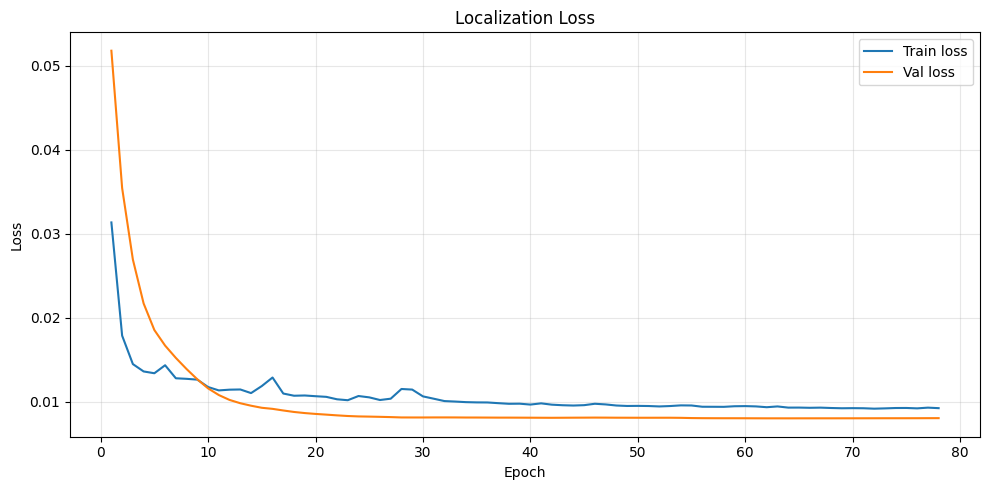

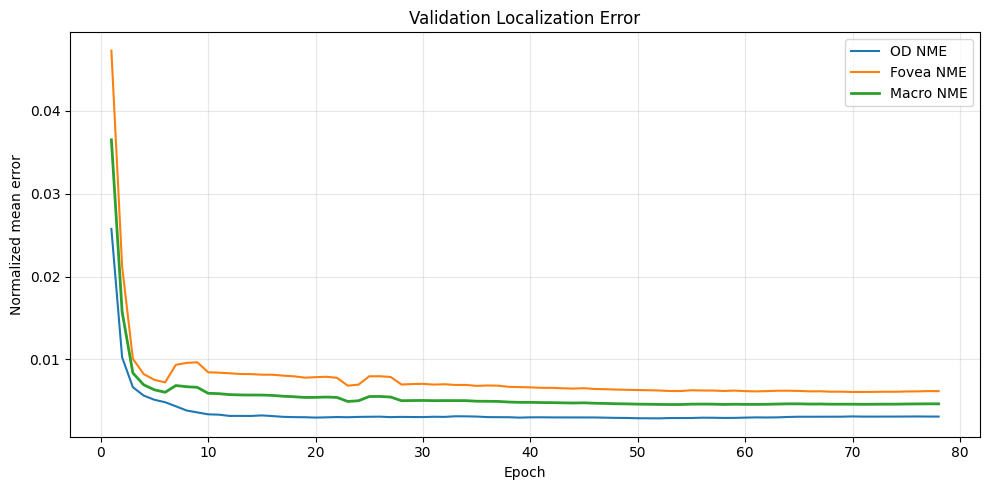

In [18]:

# ============================================================
# 18. Learning curves
# ============================================================
hist=pd.DataFrame(history); display(hist.tail())

plt.figure(figsize=(10,5))
plt.plot(hist.epoch,hist.train_loss,label="Train loss")
plt.plot(hist.epoch,hist.val_loss,label="Val loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Localization Loss"); plt.grid(alpha=.3); plt.legend(); plt.tight_layout()
plt.savefig(OUTPUT_DIR/"localization_loss_curve.png",dpi=160); plt.show()

plt.figure(figsize=(10,5))
plt.plot(hist.epoch,hist.od_mean_nme,label="OD NME")
plt.plot(hist.epoch,hist.fv_mean_nme,label="Fovea NME")
plt.plot(hist.epoch,hist.macro_mean_nme,label="Macro NME",linewidth=2)
plt.xlabel("Epoch"); plt.ylabel("Normalized mean error"); plt.title("Validation Localization Error")
plt.grid(alpha=.3); plt.legend(); plt.tight_layout()
plt.savefig(OUTPUT_DIR/"localization_nme_curve.png",dpi=160); plt.show()


In [19]:

# ============================================================
# 19. Top-K checkpoint averaging vs best single EMA using validation TTA
# ============================================================
def load_model(state):
    m=DenseNet121LocalizationNet(NUM_LANDMARKS,pretrained=False).to(DEVICE)
    m.load_state_dict(state); m.eval(); m.freeze_encoder_batchnorm()
    return m

def average_topk(items):
    if not items: return None
    avg=None; n=0
    for _,p in items:
        sd=torch.load(p,map_location="cpu")["model_state_dict"]
        if avg is None:
            avg={k:(v.clone().float() if torch.is_floating_point(v) else v.clone()) for k,v in sd.items()}
        else:
            for k,v in sd.items():
                if torch.is_floating_point(v): avg[k]+=v.float()
        n+=1
    for k in avg:
        if torch.is_floating_point(avg[k]): avg[k]/=float(n)
    return avg

best_ckpt=torch.load(BEST_CKPT,map_location="cpu")
single_model=load_model(best_ckpt["model_state_dict"])
avg_state=average_topk(topk)
avg_model=None
if avg_state is not None:
    torch.save({"model_state_dict":avg_state,"source":"topk_average","topk":[(s,str(p)) for s,p in topk]},AVERAGED_CKPT)
    avg_model=load_model(avg_state)

single_df,single_met=evaluate(single_model,val_loader,with_loss=True,tta=True)
print("Best single EMA + TTA validation macro NME:",single_met["macro_mean_nme"])

if avg_model is not None:
    avg_df,avg_met=evaluate(avg_model,val_loader,with_loss=True,tta=True)
    print(f"Top-{len(topk)} average + TTA validation macro NME:",avg_met["macro_mean_nme"])
else:
    avg_df,avg_met=None,None

if avg_met is not None and avg_met["macro_mean_nme"]<single_met["macro_mean_nme"]:
    best_model,final_val_df,final_val_metrics,MODEL_SOURCE=avg_model,avg_df,avg_met,f"top{len(topk)}_checkpoint_average"
else:
    best_model,final_val_df,final_val_metrics,MODEL_SOURCE=single_model,single_df,single_met,"best_single_ema"

final_val_df.to_csv(VAL_PRED_CSV,index=False)
print("Selected model:",MODEL_SOURCE)
print(json.dumps({k:v for k,v in final_val_metrics.items() if isinstance(v,(float,int))},indent=2))


Best single EMA + TTA validation macro NME: 0.004930865358498935
Top-5 average + TTA validation macro NME: 0.004931521572677749
Selected model: best_single_ema
{
  "od_mean_px": 18.17568335106183,
  "od_median_px": 17.351960070343253,
  "od_mean_nme": 0.003530886901139353,
  "od_median_nme": 0.003370866852050918,
  "od_success_1pct_diag": 0.9879518072289156,
  "od_success_2pct_diag": 1.0,
  "od_success_5pct_diag": 1.0,
  "fv_mean_px": 32.5888128857773,
  "fv_median_px": 20.777705349022767,
  "fv_mean_nme": 0.006330843815858516,
  "fv_median_nme": 0.004036366954440347,
  "fv_success_1pct_diag": 0.8313253012048193,
  "fv_success_2pct_diag": 0.9397590361445783,
  "fv_success_5pct_diag": 1.0,
  "macro_mean_nme": 0.004930865358498935,
  "macro_mean_px": 25.382248118419568,
  "loss": 0.008089024988732424
}


In [20]:

# ============================================================
# 20. FINAL untouched official 103-image test evaluation
# ============================================================
test_pred_df,test_metrics=evaluate(best_model,test_loader,with_loss=False,tta=USE_TTA)
test_pred_df.to_csv(TEST_PRED_CSV,index=False)
with open(TEST_METRICS_JSON,"w") as f: json.dump(test_metrics,f,indent=2)

print("OFFICIAL TEST RESULTS")
print("="*72)
for k,v in test_metrics.items(): print(f"{k:30s}: {v:.6f}")


OFFICIAL TEST RESULTS
od_mean_px                    : 18.015893
od_median_px                  : 16.278924
od_mean_nme                   : 0.003500
od_median_nme                 : 0.003162
od_success_1pct_diag          : 0.990291
od_success_2pct_diag          : 1.000000
od_success_5pct_diag          : 1.000000
fv_mean_px                    : 43.647345
fv_median_px                  : 23.532543
fv_mean_nme                   : 0.008479
fv_median_nme                 : 0.004572
fv_success_1pct_diag          : 0.786408
fv_success_2pct_diag          : 0.941748
fv_success_5pct_diag          : 0.980583
macro_mean_nme                : 0.005989
macro_mean_px                 : 30.831619


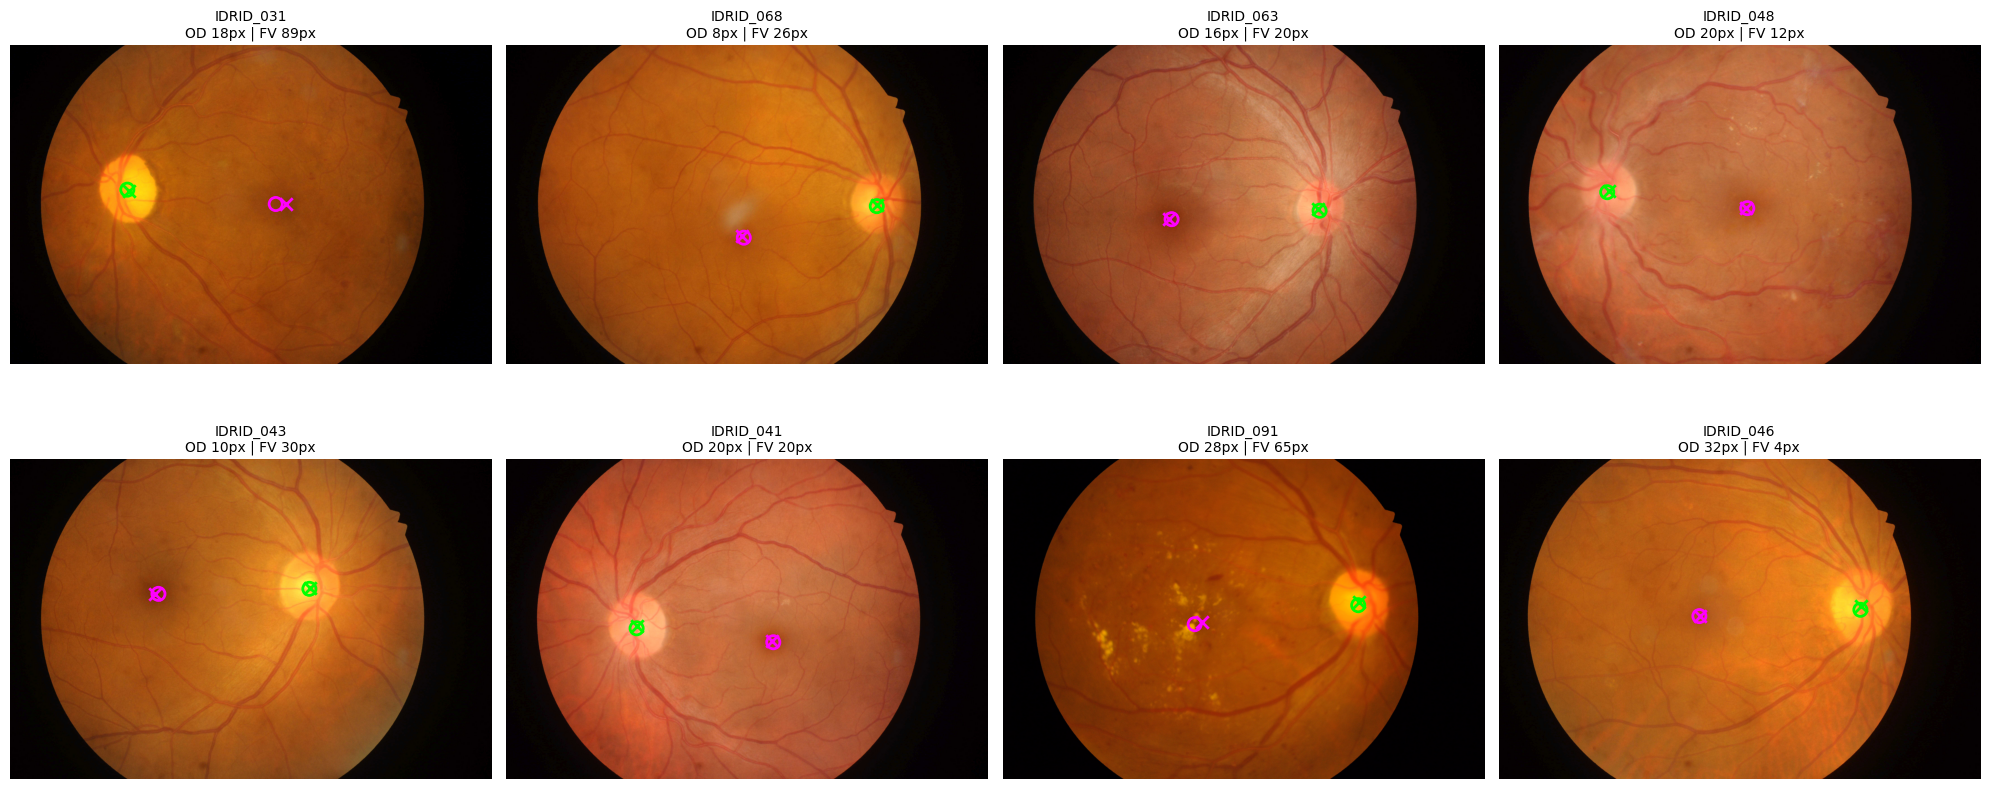

In [21]:

# ============================================================
# 21. Visualize official-test predictions
# GT=circle, prediction=X | OD=green, fovea=magenta
# ============================================================
def visualize(df,n=8):
    sample=df.sample(min(n,len(df)),random_state=SEED)
    cols=4; rows=math.ceil(len(sample)/cols); fig=plt.figure(figsize=(5*cols,4.5*rows))
    for i,(_,r) in enumerate(sample.iterrows(),1):
        ax=fig.add_subplot(rows,cols,i)
        img=cv2.cvtColor(cv2.imread(str(r.image_path)),cv2.COLOR_BGR2RGB); ax.imshow(img)
        ax.scatter([r.gt_od_x],[r.gt_od_y],s=90,facecolors="none",edgecolors="lime",linewidths=2)
        ax.scatter([r.gt_fv_x],[r.gt_fv_y],s=90,facecolors="none",edgecolors="magenta",linewidths=2)
        ax.scatter([r.pred_od_x],[r.pred_od_y],s=80,c="lime",marker="x",linewidths=2)
        ax.scatter([r.pred_fv_x],[r.pred_fv_y],s=80,c="magenta",marker="x",linewidths=2)
        ax.set_title(f"{r.image_id}\nOD {r.od_error_px:.0f}px | FV {r.fv_error_px:.0f}px",fontsize=10); ax.axis("off")
    plt.tight_layout(); plt.savefig(OUTPUT_DIR/"localization_test_prediction_examples.png",dpi=160,bbox_inches="tight"); plt.show()
visualize(test_pred_df)


In [22]:

# ============================================================
# 22. Save final deployment bundle + plain weights
# ============================================================
final_state={k:v.detach().cpu() for k,v in best_model.state_dict().items()}
bundle={
    "architecture":"DenseNet121_scSE_Attention_Heatmap_Decoder_DeepSupervision",
    "task":"IDRiD optic-disc and fovea center localization",
    "model_state_dict":final_state,"model_source":MODEL_SOURCE,
    "landmark_order":["optic_disc","fovea"],
    "input_size_wh":[INPUT_W,INPUT_H],"heatmap_size_wh":[HEATMAP_W,HEATMAP_H],
    "output_stride":OUTPUT_STRIDE,"heatmap_sigma":HEATMAP_SIGMA,
    "normalization":{"mean":IMAGENET_MEAN.tolist(),"std":IMAGENET_STD.tolist(),"channel_order":"RGB","input_range":[0.,1.]},
    "preprocessing":{"resize":"aspect-preserving letterbox","padding":"black","target_wh":[INPUT_W,INPUT_H]},
    "coordinate_convention":"x=column from left, y=row from top; output converted to original-image pixels",
    "tta":"identity+hflip+vflip+hvflip" if USE_TTA else "none",
    "config":CONFIG,"best_single_checkpoint_epoch":int(best_ckpt["epoch"]),
    "final_validation_metrics_tta":final_val_metrics,"official_test_metrics_tta":test_metrics,
}
torch.save(bundle,FINAL_BUNDLE); torch.save(final_state,PLAIN_WEIGHTS)
print("Main deployment bundle:",FINAL_BUNDLE)
print("Plain weights:",PLAIN_WEIGHTS)


Main deployment bundle: /kaggle/working/idrid_densenet121_localization_maxquality_bundle.pth
Plain weights: /kaggle/working/idrid_densenet121_localization_state_dict.pth


In [23]:

# ============================================================
# 23. Optional ONNX export
# ============================================================
if EXPORT_ONNX:
    try:
        dummy=torch.randn(1,3,INPUT_H,INPUT_W,device=DEVICE)
        torch.onnx.export(
            best_model.eval(),dummy,str(ONNX_PATH),
            input_names=["fundus_rgb"],output_names=["landmark_heatmaps"],
            dynamic_axes={"fundus_rgb":{0:"batch"},"landmark_heatmaps":{0:"batch"}},
            opset_version=17,do_constant_folding=True,
        )
        print("ONNX saved:",ONNX_PATH)
    except Exception as e:
        print("ONNX export skipped due to:",repr(e))


ONNX export skipped due to: ModuleNotFoundError("No module named 'onnxscript'")


In [24]:

# ============================================================
# 24. Zip outputs safely (exclude cache and the ZIP itself)
# ============================================================
import zipfile

if CACHE_DIR.exists():
    shutil.rmtree(CACHE_DIR, ignore_errors=True)

zip_path = OUTPUT_DIR / "IDRiD_DenseNet121_Localization_MaxQuality_Outputs.zip"
files_to_zip = [
    p for p in OUTPUT_DIR.rglob("*")
    if p.is_file() and p != zip_path and CACHE_DIR not in p.parents
]

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for p in files_to_zip:
        zf.write(p, arcname=str(p.relative_to(OUTPUT_DIR)))

print("ZIP:", zip_path)
for p in sorted(OUTPUT_DIR.rglob("*")):
    if p.is_file():
        print(f"{p.relative_to(OUTPUT_DIR)} ({p.stat().st_size/1e6:.2f} MB)")


ZIP: /kaggle/working/IDRiD_DenseNet121_Localization_MaxQuality_Outputs.zip
IDRiD_DenseNet121_Localization_MaxQuality_Outputs.zip (763.93 MB)
__notebook__.ipynb (3.43 MB)
idrid_densenet121_localization_best.pth (90.54 MB)
idrid_densenet121_localization_maxquality_bundle.pth (90.55 MB)
idrid_densenet121_localization_state_dict.pth (90.54 MB)
idrid_densenet121_localization_topk_avg.pth (90.54 MB)
idrid_localization_official_test_metrics.json (0.00 MB)
idrid_localization_official_test_predictions.csv (0.04 MB)
idrid_localization_topk/epoch_052_nme_0.004576.pth (90.53 MB)
idrid_localization_topk/epoch_053_nme_0.004565.pth (90.53 MB)
idrid_localization_topk/epoch_054_nme_0.004565.pth (90.53 MB)
idrid_localization_topk/epoch_058_nme_0.004575.pth (90.53 MB)
idrid_localization_topk/epoch_060_nme_0.004582.pth (90.53 MB)
idrid_localization_training_history.csv (0.02 MB)
idrid_localization_validation_predictions_tta.csv (0.03 MB)
localization_groundtruth_audit.png (1.75 MB)
localization_loss_curve


## Main files to keep

- `idrid_densenet121_localization_best.pth`
- `idrid_densenet121_localization_topk_avg.pth`
- `idrid_densenet121_localization_maxquality_bundle.pth` — final automatically selected deployment model
- `idrid_densenet121_localization_state_dict.pth`
- `idrid_densenet121_localization.onnx`
- `idrid_localization_official_test_predictions.csv`
- `idrid_localization_official_test_metrics.json`

### Error-prevention measures copied from the corrected segmentation workflow

The notebook refuses to proceed if the wrong task subtree is selected, the 413/103 counts are wrong, required OD/fovea CSVs are missing/duplicated, image and CSV IDs disagree, coordinates are invalid, or train/validation/test paths overlap.

It also avoids version-sensitive Albumentations calls and keeps the same robust DenseNet/EMA/checkpointing style used in the corrected segmentation notebook.
